In [ ]:
import pandas as pd
encodings = ['utf-8', 'latin1', 'ISO-8859-1', 'cp1252']

for enc in encodings:
    try:
        df = pd.read_csv('/content/road-accidents dataset.csv', encoding=enc)
        print(f"Worked with encoding: {enc}")
        break
    except Exception as e:
        print(f"Failed with encoding {enc} — {e}")



Failed with encoding utf-8 — 'utf-8' codec can't decode byte 0xc9 in position 18: invalid continuation byte
Worked with encoding: latin1


In [ ]:
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
df_shuffled.to_csv('shuffled_dataset.csv', index=False, encoding='latin1')

In [ ]:
import pandas as pd

df = pd.read_csv("/content/shuffled_dataset.csv", encoding="latin1")

print(df.shape)
print(df.columns)
df.head()


(1571, 27)
Index(['S/N', 'NAME OF THE PS ', 'CR NO', 'DATE OF REPORT', 'SEC OF LAW',
       'CRIME HEAD', 'ROAD TYPE', 'DATE OF OCCURRENCE', 'TIME OF OCCURRENCE',
       'PLACE OF OCCURRENCE ', 'PLACE OF OCCURRENCE RURAL V/R URBAN',
       'ROAD TYPE \n(NH, SH, DR TOWN, VILLAGE ROAD)', 'VICTIM  VEHICLE',
       'ACCUSED VEHICLE', 'DEATHS: MALE AGES', 'DEATHS FEMALE AGES',
       'GREVIOUS INJURED: MALE AGES', 'GREVIOUS INJURED: FEMALE AGES',
       'SIMPLE INJURED : MALE AGES\n', 'SIMPLE INJURED : FEMALE AGES\n',
       'IF PEDESTRIAN AGE : MALE AGE', 'IF PEDESTRIAN AGE : FEMALE AGE',
       'MALE ACCUSED AGE', 'FEMALE ACCUSED AGE',
       'DRIVING LICENCE       (YES V/R NO V/R NOT KNOWN)',
       'INSURANCE   (YES V/R NO V/R NOT KNOWN)', 'WEATHER CONDITION'],
      dtype='object')


,S/N,NAME OF THE PS,CR NO,DATE OF REPORT,SEC OF LAW,CRIME HEAD,ROAD TYPE,DATE OF OCCURRENCE,TIME OF OCCURRENCE,PLACE OF OCCURRENCE,...,GREVIOUS INJURED: FEMALE AGES,SIMPLE INJURED : MALE AGES\n,SIMPLE INJURED : FEMALE AGES\n,IF PEDESTRIAN AGE : MALE AGE,IF PEDESTRIAN AGE : FEMALE AGE,MALE ACCUSED AGE,FEMALE ACCUSED AGE,DRIVING LICENCE (YES V/R NO V/R NOT KNOWN),INSURANCE (YES V/R NO V/R NOT KNOWN),WEATHER CONDITION
0,9,Masti PS,0056/2023,25-04-2023,"IPC 1860 U/s: 337,279",MOTOR VEHICLE ACCIDENTS NON-FATAL,Other Roads,14-04-2023,11:30,TEKAL- BANGARPET ROAD,...,NaN,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,30,Vemagal PS,0230/2024,15-10-2024,"THE BHARATIYA NYAYA SANHITA (BNS), 2023 U/s: 2...",MOTOR VEHICLE ACCIDENTS NON-FATAL,Other Roads,09-10-2024,08:00,"NEAR BEDDALIGATE, KOLAR Tq",...,NaN,32,NaN,NaN,NaN,30,NaN,Yes,Yes,Good
2,121,Kolar Rural PS,0505/2023,13-10-2023,"IPC 1860 U/s: 279,304(A)",MOTOR VEHICLE ACCIDENTS FATAL,National Highways,13-10-2023,18:30,"THAMBIHALLI GATE, KOLAR TALUK",...,NaN,NaN,NaN,65,NaN,26,NaN,NaN,NaN,NaN
3,7,Mulbagal Town PS,0013/2023,10-02-2023,"IPC 1860 U/s: 279,337 INDIAN MOTOR VEHICLES AC...",MOTOR VEHICLE ACCIDENTS NON-FATAL,National Highways,10-02-2023,08:10,"NH-75 NARASIMHATHEERTHA, MULBAGAL TOWN",...,NaN,"58, 45",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7,Kolar Rural PS,0189/2024,08-05-2024,"IPC 1860 U/s: 304(A),279",MOTOR VEHICLE ACCIDENTS FATAL,National Highways,07-05-2024,21:30,CHALUVANAHALLI GATE,...,NaN,NaN,NaN,NaN,NaN,22,NaN,YES,YES,GOOD


preprocessing each one starting from weather

In [ ]:
import re

# convert to string and uppercase
df['WEATHER CONDITION'] = df['WEATHER CONDITION'].astype(str).str.upper()

# remove commas / extra spaces
df['WEATHER CONDITION'] = df['WEATHER CONDITION'].apply(lambda x: re.sub(r'[^A-Z ]', '', x).strip())

# replace multiple spaces with one space
df['WEATHER CONDITION'] = df['WEATHER CONDITION'].apply(lambda x: re.sub(r'\s+', ' ', x))

# fix common spelling mistakes
df['WEATHER CONDITION'] = df['WEATHER CONDITION'].replace({
    'CLUDY': 'CLOUDY',
    'CLDY': 'CLOUDY',
    'GOOD ': 'GOOD',
    'GODD': 'GOOD',
    '': 'UNKNOWN'
})


In [ ]:
df['WEATHER CONDITION'] = df['WEATHER CONDITION'].replace({
    'GOOD': 'GOOD',
    'CLOUDY': 'CLOUDY',
    'RAIN': 'RAINY',
    'SUNNY': 'SUNNY',
    'UNKNOWN': 'UNKNOWN'
})

# if any other values remain, map as UNKNOWN
allowed_values = ['GOOD', 'CLOUDY', 'RAINY', 'SUNNY', 'UNKNOWN']
df['WEATHER CONDITION'] = df['WEATHER CONDITION'].apply(lambda x: x if x in allowed_values else 'UNKNOWN')


In [ ]:
df['WEATHER CONDITION'].value_counts()


,count
WEATHER CONDITION,
UNKNOWN,774
GOOD,754
CLOUDY,43


In [ ]:
df.head()

,S/N,NAME OF THE PS,CR NO,DATE OF REPORT,SEC OF LAW,CRIME HEAD,ROAD TYPE,DATE OF OCCURRENCE,TIME OF OCCURRENCE,PLACE OF OCCURRENCE,...,GREVIOUS INJURED: FEMALE AGES,SIMPLE INJURED : MALE AGES\n,SIMPLE INJURED : FEMALE AGES\n,IF PEDESTRIAN AGE : MALE AGE,IF PEDESTRIAN AGE : FEMALE AGE,MALE ACCUSED AGE,FEMALE ACCUSED AGE,DRIVING LICENCE (YES V/R NO V/R NOT KNOWN),INSURANCE (YES V/R NO V/R NOT KNOWN),WEATHER CONDITION
0,9,Masti PS,0056/2023,25-04-2023,"IPC 1860 U/s: 337,279",MOTOR VEHICLE ACCIDENTS NON-FATAL,Other Roads,14-04-2023,11:30,TEKAL- BANGARPET ROAD,...,NaN,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
1,30,Vemagal PS,0230/2024,15-10-2024,"THE BHARATIYA NYAYA SANHITA (BNS), 2023 U/s: 2...",MOTOR VEHICLE ACCIDENTS NON-FATAL,Other Roads,09-10-2024,08:00,"NEAR BEDDALIGATE, KOLAR Tq",...,NaN,32,NaN,NaN,NaN,30,NaN,Yes,Yes,GOOD
2,121,Kolar Rural PS,0505/2023,13-10-2023,"IPC 1860 U/s: 279,304(A)",MOTOR VEHICLE ACCIDENTS FATAL,National Highways,13-10-2023,18:30,"THAMBIHALLI GATE, KOLAR TALUK",...,NaN,NaN,NaN,65,NaN,26,NaN,NaN,NaN,UNKNOWN
3,7,Mulbagal Town PS,0013/2023,10-02-2023,"IPC 1860 U/s: 279,337 INDIAN MOTOR VEHICLES AC...",MOTOR VEHICLE ACCIDENTS NON-FATAL,National Highways,10-02-2023,08:10,"NH-75 NARASIMHATHEERTHA, MULBAGAL TOWN",...,NaN,"58, 45",NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
4,7,Kolar Rural PS,0189/2024,08-05-2024,"IPC 1860 U/s: 304(A),279",MOTOR VEHICLE ACCIDENTS FATAL,National Highways,07-05-2024,21:30,CHALUVANAHALLI GATE,...,NaN,NaN,NaN,NaN,NaN,22,NaN,YES,YES,GOOD


date of report

In [ ]:
df['DATE OF REPORT'] = pd.to_datetime(
    df['DATE OF REPORT'],
    dayfirst=True,
    errors='coerce'
)
df['DATE OF REPORT'].isna().sum()

np.int64(0)

In [ ]:
#df['DATE OF REPORT'] = pd.to_datetime(df['DATE OF REPORT'], dayfirst=True, errors='coerce')

df['DATE OF REPORT'] = df['DATE OF REPORT'].astype('int64') // 10**9    # convert to seconds



In [ ]:
display(df)

,S/N,NAME OF THE PS,CR NO,DATE OF REPORT,SEC OF LAW,CRIME HEAD,ROAD TYPE,DATE OF OCCURRENCE,TIME OF OCCURRENCE,PLACE OF OCCURRENCE,...,GREVIOUS INJURED: FEMALE AGES,SIMPLE INJURED : MALE AGES\n,SIMPLE INJURED : FEMALE AGES\n,IF PEDESTRIAN AGE : MALE AGE,IF PEDESTRIAN AGE : FEMALE AGE,MALE ACCUSED AGE,FEMALE ACCUSED AGE,DRIVING LICENCE (YES V/R NO V/R NOT KNOWN),INSURANCE (YES V/R NO V/R NOT KNOWN),WEATHER CONDITION
0,9,Masti PS,0056/2023,1682380800,"IPC 1860 U/s: 337,279",MOTOR VEHICLE ACCIDENTS NON-FATAL,Other Roads,14-04-2023,11:30,TEKAL- BANGARPET ROAD,...,NaN,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
1,30,Vemagal PS,0230/2024,1728950400,"THE BHARATIYA NYAYA SANHITA (BNS), 2023 U/s: 2...",MOTOR VEHICLE ACCIDENTS NON-FATAL,Other Roads,09-10-2024,08:00,"NEAR BEDDALIGATE, KOLAR Tq",...,NaN,32,NaN,NaN,NaN,30,NaN,Yes,Yes,GOOD
2,121,Kolar Rural PS,0505/2023,1697155200,"IPC 1860 U/s: 279,304(A)",MOTOR VEHICLE ACCIDENTS FATAL,National Highways,13-10-2023,18:30,"THAMBIHALLI GATE, KOLAR TALUK",...,NaN,NaN,NaN,65,NaN,26,NaN,NaN,NaN,UNKNOWN
3,7,Mulbagal Town PS,0013/2023,1675987200,"IPC 1860 U/s: 279,337 INDIAN MOTOR VEHICLES AC...",MOTOR VEHICLE ACCIDENTS NON-FATAL,National Highways,10-02-2023,08:10,"NH-75 NARASIMHATHEERTHA, MULBAGAL TOWN",...,NaN,"58, 45",NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
4,7,Kolar Rural PS,0189/2024,1715126400,"IPC 1860 U/s: 304(A),279",MOTOR VEHICLE ACCIDENTS FATAL,National Highways,07-05-2024,21:30,CHALUVANAHALLI GATE,...,NaN,NaN,NaN,NaN,NaN,22,NaN,YES,YES,GOOD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1566,53,Malur PS,0256/2023,1687910400,"IPC 1860 U/s: 337,279,338",MOTOR VEHICLE ACCIDENTS NON-FATAL,State Highways,28-06-2023,10:00,ITC factory near hoskote road,...,NaN,NaN,NaN,NaN,NaN,35,NaN,NaN,NaN,UNKNOWN
1567,78,Mulbagal Rural PS,0325/2023,1702080000,"IPC 1860 U/s: 279,337",MOTOR VEHICLE ACCIDENTS NON-FATAL,Other Places,30-11-2023,19:15,Mopurahalli,...,NaN,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
1568,38,Kolar Rural PS,0165/2023,1680220800,"IPC 1860 U/s: 279,338",MOTOR VEHICLE ACCIDENTS NON-FATAL,National Highways,30-03-2023,19:00,Belaganahalli gate Bridge Near Ramasandra Gate,...,NaN,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
1569,43,Srinivasapura PS,0226/2023,1689465600,"IPC 1860 U/s: 337,279 INDIAN MOTOR VEHICLES AC...",MOTOR VEHICLE ACCIDENTS NON-FATAL,State Highways,14-07-2023,18:00,BYRAPALLY NEAR GAS GOADAN,...,NaN,33,NaN,NaN,NaN,34,NaN,NaN,NaN,UNKNOWN


date of occurence

In [ ]:
df['DATE OF OCCURRENCE'] = pd.to_datetime(
    df['DATE OF OCCURRENCE'],
    dayfirst=True,
    errors='coerce'
)
df['DATE OF OCCURRENCE'].isna().sum()

np.int64(72)

In [ ]:
#df['DATE OF OCCURRENCE'] = pd.to_datetime(df['DATE OF OCCURRENCE'], dayfirst=True, errors='coerce')

df['DATE OF OCCURRENCE'] = df['DATE OF OCCURRENCE'].astype('int64') // 10**9    # convert to seconds




In [ ]:
display(df)

,S/N,NAME OF THE PS,CR NO,DATE OF REPORT,SEC OF LAW,CRIME HEAD,ROAD TYPE,DATE OF OCCURRENCE,TIME OF OCCURRENCE,PLACE OF OCCURRENCE,...,GREVIOUS INJURED: FEMALE AGES,SIMPLE INJURED : MALE AGES\n,SIMPLE INJURED : FEMALE AGES\n,IF PEDESTRIAN AGE : MALE AGE,IF PEDESTRIAN AGE : FEMALE AGE,MALE ACCUSED AGE,FEMALE ACCUSED AGE,DRIVING LICENCE (YES V/R NO V/R NOT KNOWN),INSURANCE (YES V/R NO V/R NOT KNOWN),WEATHER CONDITION
0,9,Masti PS,0056/2023,1682380800,"IPC 1860 U/s: 337,279",MOTOR VEHICLE ACCIDENTS NON-FATAL,Other Roads,1681430400,11:30,TEKAL- BANGARPET ROAD,...,NaN,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
1,30,Vemagal PS,0230/2024,1728950400,"THE BHARATIYA NYAYA SANHITA (BNS), 2023 U/s: 2...",MOTOR VEHICLE ACCIDENTS NON-FATAL,Other Roads,1728432000,08:00,"NEAR BEDDALIGATE, KOLAR Tq",...,NaN,32,NaN,NaN,NaN,30,NaN,Yes,Yes,GOOD
2,121,Kolar Rural PS,0505/2023,1697155200,"IPC 1860 U/s: 279,304(A)",MOTOR VEHICLE ACCIDENTS FATAL,National Highways,1697155200,18:30,"THAMBIHALLI GATE, KOLAR TALUK",...,NaN,NaN,NaN,65,NaN,26,NaN,NaN,NaN,UNKNOWN
3,7,Mulbagal Town PS,0013/2023,1675987200,"IPC 1860 U/s: 279,337 INDIAN MOTOR VEHICLES AC...",MOTOR VEHICLE ACCIDENTS NON-FATAL,National Highways,1675987200,08:10,"NH-75 NARASIMHATHEERTHA, MULBAGAL TOWN",...,NaN,"58, 45",NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
4,7,Kolar Rural PS,0189/2024,1715126400,"IPC 1860 U/s: 304(A),279",MOTOR VEHICLE ACCIDENTS FATAL,National Highways,1715040000,21:30,CHALUVANAHALLI GATE,...,NaN,NaN,NaN,NaN,NaN,22,NaN,YES,YES,GOOD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1566,53,Malur PS,0256/2023,1687910400,"IPC 1860 U/s: 337,279,338",MOTOR VEHICLE ACCIDENTS NON-FATAL,State Highways,1687910400,10:00,ITC factory near hoskote road,...,NaN,NaN,NaN,NaN,NaN,35,NaN,NaN,NaN,UNKNOWN
1567,78,Mulbagal Rural PS,0325/2023,1702080000,"IPC 1860 U/s: 279,337",MOTOR VEHICLE ACCIDENTS NON-FATAL,Other Places,1701302400,19:15,Mopurahalli,...,NaN,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
1568,38,Kolar Rural PS,0165/2023,1680220800,"IPC 1860 U/s: 279,338",MOTOR VEHICLE ACCIDENTS NON-FATAL,National Highways,1680134400,19:00,Belaganahalli gate Bridge Near Ramasandra Gate,...,NaN,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
1569,43,Srinivasapura PS,0226/2023,1689465600,"IPC 1860 U/s: 337,279 INDIAN MOTOR VEHICLES AC...",MOTOR VEHICLE ACCIDENTS NON-FATAL,State Highways,1689292800,18:00,BYRAPALLY NEAR GAS GOADAN,...,NaN,33,NaN,NaN,NaN,34,NaN,NaN,NaN,UNKNOWN


road type

In [ ]:
import re

# Convert to string and uppercase
df['ROAD TYPE'] = df['ROAD TYPE'].astype(str).str.upper()

# Remove extra spaces and unwanted characters
df['ROAD TYPE'] = df['ROAD TYPE'].apply(lambda x: re.sub(r'[^A-Z ]', '', x).strip())

# Replace common variations
df['ROAD TYPE'] = df['ROAD TYPE'].replace({
    'NATIONAL HIGHWYS': 'NATIONAL HIGHWAYS',
    'NATIONAL HIGHW': 'NATIONAL HIGHWAYS',
    'STATE HIGHWYS': 'STATE HIGHWAYS',
    'OTHER ROAD': 'OTHER ROADS',
    'OTHERS ROAD': 'OTHER ROADS',
})
valid_road_types = ['NATIONAL HIGHWAYS', 'STATE HIGHWAYS', 'OTHER ROADS']

df['ROAD TYPE'] = df['ROAD TYPE'].apply(
    lambda x: x if x in valid_road_types else 'OTHER ROADS'  # Merge unusual values
)



In [ ]:
df.head()

,S/N,NAME OF THE PS,CR NO,DATE OF REPORT,SEC OF LAW,CRIME HEAD,ROAD TYPE,DATE OF OCCURRENCE,TIME OF OCCURRENCE,PLACE OF OCCURRENCE,...,GREVIOUS INJURED: FEMALE AGES,SIMPLE INJURED : MALE AGES\n,SIMPLE INJURED : FEMALE AGES\n,IF PEDESTRIAN AGE : MALE AGE,IF PEDESTRIAN AGE : FEMALE AGE,MALE ACCUSED AGE,FEMALE ACCUSED AGE,DRIVING LICENCE (YES V/R NO V/R NOT KNOWN),INSURANCE (YES V/R NO V/R NOT KNOWN),WEATHER CONDITION
0,9,Masti PS,0056/2023,1682380800,"IPC 1860 U/s: 337,279",MOTOR VEHICLE ACCIDENTS NON-FATAL,OTHER ROADS,1681430400,11:30,TEKAL- BANGARPET ROAD,...,NaN,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
1,30,Vemagal PS,0230/2024,1728950400,"THE BHARATIYA NYAYA SANHITA (BNS), 2023 U/s: 2...",MOTOR VEHICLE ACCIDENTS NON-FATAL,OTHER ROADS,1728432000,08:00,"NEAR BEDDALIGATE, KOLAR Tq",...,NaN,32,NaN,NaN,NaN,30,NaN,Yes,Yes,GOOD
2,121,Kolar Rural PS,0505/2023,1697155200,"IPC 1860 U/s: 279,304(A)",MOTOR VEHICLE ACCIDENTS FATAL,NATIONAL HIGHWAYS,1697155200,18:30,"THAMBIHALLI GATE, KOLAR TALUK",...,NaN,NaN,NaN,65,NaN,26,NaN,NaN,NaN,UNKNOWN
3,7,Mulbagal Town PS,0013/2023,1675987200,"IPC 1860 U/s: 279,337 INDIAN MOTOR VEHICLES AC...",MOTOR VEHICLE ACCIDENTS NON-FATAL,NATIONAL HIGHWAYS,1675987200,08:10,"NH-75 NARASIMHATHEERTHA, MULBAGAL TOWN",...,NaN,"58, 45",NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
4,7,Kolar Rural PS,0189/2024,1715126400,"IPC 1860 U/s: 304(A),279",MOTOR VEHICLE ACCIDENTS FATAL,NATIONAL HIGHWAYS,1715040000,21:30,CHALUVANAHALLI GATE,...,NaN,NaN,NaN,NaN,NaN,22,NaN,YES,YES,GOOD


place of occurence

In [ ]:
import re

#convert to string & uppercase
df['PLACE OF OCCURRENCE RURAL V/R URBAN'] = df['PLACE OF OCCURRENCE RURAL V/R URBAN'].astype(str).str.upper()

#remove symbols & extra spaces
df['PLACE OF OCCURRENCE RURAL V/R URBAN'] = df['PLACE OF OCCURRENCE RURAL V/R URBAN'].apply(lambda x: re.sub(r'[^A-Z ]', '', x).strip())

#correct common spelling mistakes
df['PLACE OF OCCURRENCE RURAL V/R URBAN'] = df['PLACE OF OCCURRENCE RURAL V/R URBAN'].replace({
    'URBEN': 'URBAN',
    'URABN': 'URBAN',
    'URB': 'URBAN',
    'RURUL': 'RURAL',
})

#keep only valid values
df['PLACE OF OCCURRENCE RURAL V/R URBAN'] = df['PLACE OF OCCURRENCE RURAL V/R URBAN'].apply(
    lambda x: 'RURAL' if 'RURAL' in x
    else 'URBAN' if 'URBAN' in x
    else 'UNKNOWN'
)



In [ ]:
display(df)

,S/N,NAME OF THE PS,CR NO,DATE OF REPORT,SEC OF LAW,CRIME HEAD,ROAD TYPE,DATE OF OCCURRENCE,TIME OF OCCURRENCE,PLACE OF OCCURRENCE,...,GREVIOUS INJURED: FEMALE AGES,SIMPLE INJURED : MALE AGES\n,SIMPLE INJURED : FEMALE AGES\n,IF PEDESTRIAN AGE : MALE AGE,IF PEDESTRIAN AGE : FEMALE AGE,MALE ACCUSED AGE,FEMALE ACCUSED AGE,DRIVING LICENCE (YES V/R NO V/R NOT KNOWN),INSURANCE (YES V/R NO V/R NOT KNOWN),WEATHER CONDITION
0,9,Masti PS,0056/2023,1682380800,"IPC 1860 U/s: 337,279",MOTOR VEHICLE ACCIDENTS NON-FATAL,OTHER ROADS,1681430400,11:30,TEKAL- BANGARPET ROAD,...,NaN,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
1,30,Vemagal PS,0230/2024,1728950400,"THE BHARATIYA NYAYA SANHITA (BNS), 2023 U/s: 2...",MOTOR VEHICLE ACCIDENTS NON-FATAL,OTHER ROADS,1728432000,08:00,"NEAR BEDDALIGATE, KOLAR Tq",...,NaN,32,NaN,NaN,NaN,30,NaN,Yes,Yes,GOOD
2,121,Kolar Rural PS,0505/2023,1697155200,"IPC 1860 U/s: 279,304(A)",MOTOR VEHICLE ACCIDENTS FATAL,NATIONAL HIGHWAYS,1697155200,18:30,"THAMBIHALLI GATE, KOLAR TALUK",...,NaN,NaN,NaN,65,NaN,26,NaN,NaN,NaN,UNKNOWN
3,7,Mulbagal Town PS,0013/2023,1675987200,"IPC 1860 U/s: 279,337 INDIAN MOTOR VEHICLES AC...",MOTOR VEHICLE ACCIDENTS NON-FATAL,NATIONAL HIGHWAYS,1675987200,08:10,"NH-75 NARASIMHATHEERTHA, MULBAGAL TOWN",...,NaN,"58, 45",NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
4,7,Kolar Rural PS,0189/2024,1715126400,"IPC 1860 U/s: 304(A),279",MOTOR VEHICLE ACCIDENTS FATAL,NATIONAL HIGHWAYS,1715040000,21:30,CHALUVANAHALLI GATE,...,NaN,NaN,NaN,NaN,NaN,22,NaN,YES,YES,GOOD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1566,53,Malur PS,0256/2023,1687910400,"IPC 1860 U/s: 337,279,338",MOTOR VEHICLE ACCIDENTS NON-FATAL,STATE HIGHWAYS,1687910400,10:00,ITC factory near hoskote road,...,NaN,NaN,NaN,NaN,NaN,35,NaN,NaN,NaN,UNKNOWN
1567,78,Mulbagal Rural PS,0325/2023,1702080000,"IPC 1860 U/s: 279,337",MOTOR VEHICLE ACCIDENTS NON-FATAL,OTHER ROADS,1701302400,19:15,Mopurahalli,...,NaN,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
1568,38,Kolar Rural PS,0165/2023,1680220800,"IPC 1860 U/s: 279,338",MOTOR VEHICLE ACCIDENTS NON-FATAL,NATIONAL HIGHWAYS,1680134400,19:00,Belaganahalli gate Bridge Near Ramasandra Gate,...,NaN,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
1569,43,Srinivasapura PS,0226/2023,1689465600,"IPC 1860 U/s: 337,279 INDIAN MOTOR VEHICLES AC...",MOTOR VEHICLE ACCIDENTS NON-FATAL,STATE HIGHWAYS,1689292800,18:00,BYRAPALLY NEAR GAS GOADAN,...,NaN,33,NaN,NaN,NaN,34,NaN,NaN,NaN,UNKNOWN


hour

In [ ]:
import re
from dateutil import parser
import numpy as np

def clean_time(x):
    x = str(x).strip().upper()


    x = x.replace('.', ':')
    x = x.replace('HRS', '')
    x = x.replace(' ', '')

    try:
        return parser.parse(x).time()
    except:
        return np.nan

df['TIME OF OCCURRENCE'] = df['TIME OF OCCURRENCE'].apply(clean_time)
df['HOUR'] = df['TIME OF OCCURRENCE'].apply(lambda x: x.hour if pd.notnull(x) else np.nan)
df.drop('TIME OF OCCURRENCE', axis=1, inplace=True)



/usr/local/lib/python3.12/dist-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname HR identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
/usr/local/lib/python3.12/dist-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname TO identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


In [ ]:
df.head()

,S/N,NAME OF THE PS,CR NO,DATE OF REPORT,SEC OF LAW,CRIME HEAD,ROAD TYPE,DATE OF OCCURRENCE,PLACE OF OCCURRENCE,PLACE OF OCCURRENCE RURAL V/R URBAN,...,SIMPLE INJURED : MALE AGES\n,SIMPLE INJURED : FEMALE AGES\n,IF PEDESTRIAN AGE : MALE AGE,IF PEDESTRIAN AGE : FEMALE AGE,MALE ACCUSED AGE,FEMALE ACCUSED AGE,DRIVING LICENCE (YES V/R NO V/R NOT KNOWN),INSURANCE (YES V/R NO V/R NOT KNOWN),WEATHER CONDITION,HOUR
0,9,Masti PS,0056/2023,1682380800,"IPC 1860 U/s: 337,279",MOTOR VEHICLE ACCIDENTS NON-FATAL,OTHER ROADS,1681430400,TEKAL- BANGARPET ROAD,RURAL,...,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN,11.0
1,30,Vemagal PS,0230/2024,1728950400,"THE BHARATIYA NYAYA SANHITA (BNS), 2023 U/s: 2...",MOTOR VEHICLE ACCIDENTS NON-FATAL,OTHER ROADS,1728432000,"NEAR BEDDALIGATE, KOLAR Tq",RURAL,...,32,NaN,NaN,NaN,30,NaN,Yes,Yes,GOOD,8.0
2,121,Kolar Rural PS,0505/2023,1697155200,"IPC 1860 U/s: 279,304(A)",MOTOR VEHICLE ACCIDENTS FATAL,NATIONAL HIGHWAYS,1697155200,"THAMBIHALLI GATE, KOLAR TALUK",RURAL,...,NaN,NaN,65,NaN,26,NaN,NaN,NaN,UNKNOWN,18.0
3,7,Mulbagal Town PS,0013/2023,1675987200,"IPC 1860 U/s: 279,337 INDIAN MOTOR VEHICLES AC...",MOTOR VEHICLE ACCIDENTS NON-FATAL,NATIONAL HIGHWAYS,1675987200,"NH-75 NARASIMHATHEERTHA, MULBAGAL TOWN",URBAN,...,"58, 45",NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN,8.0
4,7,Kolar Rural PS,0189/2024,1715126400,"IPC 1860 U/s: 304(A),279",MOTOR VEHICLE ACCIDENTS FATAL,NATIONAL HIGHWAYS,1715040000,CHALUVANAHALLI GATE,RURAL,...,NaN,NaN,NaN,NaN,22,NaN,YES,YES,GOOD,21.0


new road type

In [ ]:
import re

def clean_road_type(x):
    x = str(x).upper().strip()

    x = re.sub(r'[^A-Z0-9 ]', '', x)

    if 'NH' in x:
        return 'NATIONAL HIGHWAY'
    elif 'SH' in x:
        return 'STATE HIGHWAY'
    elif 'MDR' in x or 'DR' in x:
        return 'MAJOR DISTRICT ROAD'
    else:
        return 'OTHER ROADS'

df['ROAD TYPE \n(NH, SH, DR TOWN, VILLAGE ROAD)'] = df['ROAD TYPE \n(NH, SH, DR TOWN, VILLAGE ROAD)'].apply(clean_road_type)
df['ROAD TYPE'].value_counts()



,count
ROAD TYPE,
NATIONAL HIGHWAYS,631
OTHER ROADS,617
STATE HIGHWAYS,323


In [ ]:
print(df.columns)

Index(['S/N', 'NAME OF THE PS ', 'CR NO', 'DATE OF REPORT', 'SEC OF LAW',
       'CRIME HEAD', 'ROAD TYPE', 'DATE OF OCCURRENCE', 'PLACE OF OCCURRENCE ',
       'PLACE OF OCCURRENCE RURAL V/R URBAN',
       'ROAD TYPE \n(NH, SH, DR TOWN, VILLAGE ROAD)', 'VICTIM  VEHICLE',
       'ACCUSED VEHICLE', 'DEATHS: MALE AGES', 'DEATHS FEMALE AGES',
       'GREVIOUS INJURED: MALE AGES', 'GREVIOUS INJURED: FEMALE AGES',
       'SIMPLE INJURED : MALE AGES\n', 'SIMPLE INJURED : FEMALE AGES\n',
       'IF PEDESTRIAN AGE : MALE AGE', 'IF PEDESTRIAN AGE : FEMALE AGE',
       'MALE ACCUSED AGE', 'FEMALE ACCUSED AGE',
       'DRIVING LICENCE       (YES V/R NO V/R NOT KNOWN)',
       'INSURANCE   (YES V/R NO V/R NOT KNOWN)', 'WEATHER CONDITION', 'HOUR'],
      dtype='object')


vehicle types

In [ ]:
import re

def clean_vehicle(x):
    x = str(x).upper().strip()

    #remove registration numbers
    x = re.sub(r'[A-Z]{2}\-\d{2}.*', '', x)

    #common patterns
    if 'T/W' in x or 'TWO WHEEL' in x or '2W' in x:
        return 'TWO WHEELER'
    elif 'CAR' in x or 'AUTO' in x or 'T/E' in x:
        return 'FOUR WHEELER'
    elif 'LORRY' in x or 'TRUCK' in x or 'CONTAINER' in x or 'TRACTOR' in x:
        return 'HEAVY VEHICLE'
    elif 'BUS' in x:
        return 'BUS'
    elif 'PEDESTRIAN' in x or 'PEDASTRIAN' in x:
        return 'PEDESTRIAN'
    elif 'TEMPO' in x:
        return 'LIGHT COMMERCIAL VEHICLE'
    else:
        return 'UNKNOWN'

df['VICTIM  VEHICLE'] = df['VICTIM  VEHICLE'].apply(clean_vehicle)
df['ACCUSED VEHICLE'] = df['ACCUSED VEHICLE'].apply(clean_vehicle)


In [ ]:
print("Victim:")
print(df['VICTIM  VEHICLE'].value_counts())

print("\nAccused:")
print(df['ACCUSED VEHICLE'].value_counts())

Victim:
VICTIM  VEHICLE
TWO WHEELER                 859
UNKNOWN                     320
FOUR WHEELER                191
PEDESTRIAN                  128
HEAVY VEHICLE                43
BUS                          17
LIGHT COMMERCIAL VEHICLE     13
Name: count, dtype: int64

Accused:
ACCUSED VEHICLE
FOUR WHEELER                413
TWO WHEELER                 396
UNKNOWN                     359
HEAVY VEHICLE               253
BUS                         106
LIGHT COMMERCIAL VEHICLE     44
Name: count, dtype: int64


insurance and drivers license

In [ ]:
import re

def clean_lic_or_insur(x):
    x = str(x).strip().upper()

    if x.isdigit():
        return 'UNKNOWN'

    if 'YES' in x or 'WITH' in x:
        return 'YES'
    elif 'NO' in x:
        return 'NO'
    elif 'NOT' in x:
        return 'UNKNOWN'
    else:
        return 'UNKNOWN'

df['DRIVING LICENCE       (YES V/R NO V/R NOT KNOWN)'] = df['DRIVING LICENCE       (YES V/R NO V/R NOT KNOWN)'].apply(clean_lic_or_insur)
df['INSURANCE   (YES V/R NO V/R NOT KNOWN)'] = df['INSURANCE   (YES V/R NO V/R NOT KNOWN)'].apply(clean_lic_or_insur)


In [ ]:
print(df['DRIVING LICENCE       (YES V/R NO V/R NOT KNOWN)'].value_counts())
print(df['INSURANCE   (YES V/R NO V/R NOT KNOWN)'].value_counts())


DRIVING LICENCE       (YES V/R NO V/R NOT KNOWN)
UNKNOWN    875
YES        625
NO          71
Name: count, dtype: int64
INSURANCE   (YES V/R NO V/R NOT KNOWN)
UNKNOWN    848
YES        648
NO          75
Name: count, dtype: int64


to find total injuries and deaths

In [ ]:
import re
import numpy as np

def count_values(x):
    x = str(x).strip()
    if x in ['', '-', 'nan', 'None']:
        return 0
    # Replace '/' or ',' with comma
    x = x.replace('/', ',')
    # Extract only numbers
    numbers = re.findall(r'\d+', x)
    return len(numbers)


cols = [
    'DEATHS: MALE AGES', 'DEATHS FEMALE AGES',
    'GREVIOUS INJURED: MALE AGES', 'GREVIOUS INJURED: FEMALE AGES',
    'SIMPLE INJURED : MALE AGES\n', 'SIMPLE INJURED : FEMALE AGES\n'
]

for col in cols:
    df[col] = df[col].apply(count_values)


In [ ]:
df.columns

Index(['S/N', 'NAME OF THE PS ', 'CR NO', 'DATE OF REPORT', 'SEC OF LAW',
       'CRIME HEAD', 'ROAD TYPE', 'DATE OF OCCURRENCE', 'PLACE OF OCCURRENCE ',
       'PLACE OF OCCURRENCE RURAL V/R URBAN',
       'ROAD TYPE \n(NH, SH, DR TOWN, VILLAGE ROAD)', 'VICTIM  VEHICLE',
       'ACCUSED VEHICLE', 'DEATHS: MALE AGES', 'DEATHS FEMALE AGES',
       'GREVIOUS INJURED: MALE AGES', 'GREVIOUS INJURED: FEMALE AGES',
       'SIMPLE INJURED : MALE AGES\n', 'SIMPLE INJURED : FEMALE AGES\n',
       'IF PEDESTRIAN AGE : MALE AGE', 'IF PEDESTRIAN AGE : FEMALE AGE',
       'MALE ACCUSED AGE', 'FEMALE ACCUSED AGE',
       'DRIVING LICENCE       (YES V/R NO V/R NOT KNOWN)',
       'INSURANCE   (YES V/R NO V/R NOT KNOWN)', 'WEATHER CONDITION', 'HOUR'],
      dtype='object')

creating the columns

In [ ]:
df['TOTAL_DEATHS'] = df['DEATHS: MALE AGES'] + df['DEATHS FEMALE AGES']
df['TOTAL_GREVIOUS_INJURIES'] = df['GREVIOUS INJURED: MALE AGES'] + df['GREVIOUS INJURED: FEMALE AGES']
df['TOTAL_SIMPLE_INJURIES'] = df['SIMPLE INJURED : MALE AGES\n'] + df['SIMPLE INJURED : FEMALE AGES\n']


creating the severity column

In [ ]:
def get_severity(row):
    if row['TOTAL_DEATHS'] > 0:
        return 'FATAL'
    elif row['TOTAL_GREVIOUS_INJURIES'] > 0:
        return 'GRIEVIOUS'
    elif row['TOTAL_SIMPLE_INJURIES'] > 0:
        return 'SIMPLE'
    else:
        return 'UNKNOWN'

df['SEVERITY'] = df.apply(get_severity, axis=1)
df['SEVERITY'].value_counts()


,count
SEVERITY,
SIMPLE,514
FATAL,496
GRIEVIOUS,366
UNKNOWN,195


convert unknowns to simple

In [ ]:
df['SEVERITY'] = df['SEVERITY'].replace('UNKNOWN', 'SIMPLE')
df['SEVERITY'].value_counts()

,count
SEVERITY,
SIMPLE,709
FATAL,496
GRIEVIOUS,366


In [ ]:
display(df)

,S/N,NAME OF THE PS,CR NO,DATE OF REPORT,SEC OF LAW,CRIME HEAD,ROAD TYPE,DATE OF OCCURRENCE,PLACE OF OCCURRENCE,PLACE OF OCCURRENCE RURAL V/R URBAN,...,MALE ACCUSED AGE,FEMALE ACCUSED AGE,DRIVING LICENCE (YES V/R NO V/R NOT KNOWN),INSURANCE (YES V/R NO V/R NOT KNOWN),WEATHER CONDITION,HOUR,TOTAL_DEATHS,TOTAL_GREVIOUS_INJURIES,TOTAL_SIMPLE_INJURIES,SEVERITY
0,9,Masti PS,0056/2023,1682380800,"IPC 1860 U/s: 337,279",MOTOR VEHICLE ACCIDENTS NON-FATAL,OTHER ROADS,1681430400,TEKAL- BANGARPET ROAD,RURAL,...,NaN,NaN,UNKNOWN,UNKNOWN,UNKNOWN,11.0,0,0,1,SIMPLE
1,30,Vemagal PS,0230/2024,1728950400,"THE BHARATIYA NYAYA SANHITA (BNS), 2023 U/s: 2...",MOTOR VEHICLE ACCIDENTS NON-FATAL,OTHER ROADS,1728432000,"NEAR BEDDALIGATE, KOLAR Tq",RURAL,...,30,NaN,YES,YES,GOOD,8.0,0,0,1,SIMPLE
2,121,Kolar Rural PS,0505/2023,1697155200,"IPC 1860 U/s: 279,304(A)",MOTOR VEHICLE ACCIDENTS FATAL,NATIONAL HIGHWAYS,1697155200,"THAMBIHALLI GATE, KOLAR TALUK",RURAL,...,26,NaN,UNKNOWN,UNKNOWN,UNKNOWN,18.0,1,0,0,FATAL
3,7,Mulbagal Town PS,0013/2023,1675987200,"IPC 1860 U/s: 279,337 INDIAN MOTOR VEHICLES AC...",MOTOR VEHICLE ACCIDENTS NON-FATAL,NATIONAL HIGHWAYS,1675987200,"NH-75 NARASIMHATHEERTHA, MULBAGAL TOWN",URBAN,...,NaN,NaN,UNKNOWN,UNKNOWN,UNKNOWN,8.0,0,0,2,SIMPLE
4,7,Kolar Rural PS,0189/2024,1715126400,"IPC 1860 U/s: 304(A),279",MOTOR VEHICLE ACCIDENTS FATAL,NATIONAL HIGHWAYS,1715040000,CHALUVANAHALLI GATE,RURAL,...,22,NaN,YES,YES,GOOD,21.0,1,0,0,FATAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1566,53,Malur PS,0256/2023,1687910400,"IPC 1860 U/s: 337,279,338",MOTOR VEHICLE ACCIDENTS NON-FATAL,STATE HIGHWAYS,1687910400,ITC factory near hoskote road,URBAN,...,35,NaN,UNKNOWN,UNKNOWN,UNKNOWN,10.0,0,1,0,GRIEVIOUS
1567,78,Mulbagal Rural PS,0325/2023,1702080000,"IPC 1860 U/s: 279,337",MOTOR VEHICLE ACCIDENTS NON-FATAL,OTHER ROADS,1701302400,Mopurahalli,RURAL,...,NaN,NaN,UNKNOWN,UNKNOWN,UNKNOWN,19.0,0,0,1,SIMPLE
1568,38,Kolar Rural PS,0165/2023,1680220800,"IPC 1860 U/s: 279,338",MOTOR VEHICLE ACCIDENTS NON-FATAL,NATIONAL HIGHWAYS,1680134400,Belaganahalli gate Bridge Near Ramasandra Gate,RURAL,...,NaN,NaN,UNKNOWN,UNKNOWN,UNKNOWN,19.0,0,1,1,GRIEVIOUS
1569,43,Srinivasapura PS,0226/2023,1689465600,"IPC 1860 U/s: 337,279 INDIAN MOTOR VEHICLES AC...",MOTOR VEHICLE ACCIDENTS NON-FATAL,STATE HIGHWAYS,1689292800,BYRAPALLY NEAR GAS GOADAN,RURAL,...,34,NaN,UNKNOWN,UNKNOWN,UNKNOWN,18.0,0,0,1,SIMPLE


**LABELING THE COLUMNS**

In [ ]:
# Find categorical (object) columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))


['NAME OF THE PS ', 'CR NO', 'SEC OF LAW', 'CRIME HEAD', 'ROAD TYPE', 'PLACE OF OCCURRENCE ', 'PLACE OF OCCURRENCE RURAL V/R URBAN', 'ROAD TYPE \n(NH, SH, DR TOWN, VILLAGE ROAD)', 'VICTIM  VEHICLE', 'ACCUSED VEHICLE', 'IF PEDESTRIAN AGE : MALE AGE', 'IF PEDESTRIAN AGE : FEMALE AGE', 'MALE ACCUSED AGE', 'FEMALE ACCUSED AGE', 'DRIVING LICENCE       (YES V/R NO V/R NOT KNOWN)', 'INSURANCE   (YES V/R NO V/R NOT KNOWN)', 'WEATHER CONDITION', 'SEVERITY']


In [ ]:
display(df)

,S/N,NAME OF THE PS,CR NO,DATE OF REPORT,SEC OF LAW,CRIME HEAD,ROAD TYPE,DATE OF OCCURRENCE,PLACE OF OCCURRENCE,PLACE OF OCCURRENCE RURAL V/R URBAN,...,MALE ACCUSED AGE,FEMALE ACCUSED AGE,DRIVING LICENCE (YES V/R NO V/R NOT KNOWN),INSURANCE (YES V/R NO V/R NOT KNOWN),WEATHER CONDITION,HOUR,TOTAL_DEATHS,TOTAL_GREVIOUS_INJURIES,TOTAL_SIMPLE_INJURIES,SEVERITY
0,9,4,111,1682380800,124,1,1,1681430400,1253,0,...,75,30,1,1,2,11.0,0,0,1,2
1,30,10,424,1728950400,208,1,1,1728432000,710,0,...,23,30,2,2,1,8.0,0,0,1,2
2,121,1,725,1697155200,31,0,0,1697155200,1257,0,...,17,30,1,1,2,18.0,1,0,0,0
3,7,6,25,1675987200,64,1,0,1675987200,880,2,...,75,30,1,1,2,8.0,0,0,2,2
4,7,1,352,1715126400,107,0,0,1715040000,153,0,...,13,30,2,2,1,21.0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1566,53,3,465,1687910400,161,1,2,1687910400,337,2,...,30,30,1,1,2,10.0,0,1,0,1
1567,78,5,566,1702080000,49,1,1,1701302400,650,0,...,75,30,1,1,2,19.0,0,0,1,2
1568,38,1,310,1680220800,91,1,0,1680134400,130,0,...,75,30,1,1,2,19.0,0,1,1,1
1569,43,9,418,1689465600,138,1,2,1689292800,113,0,...,29,30,1,1,2,18.0,0,0,1,2


In [ ]:
df.to_csv("cleaned_accident_data2.csv", index=False)

## FEATURE ENGINEERING

In [ ]:
df=pd.read_csv("/content/cleaned_accident_data2.csv")

In [ ]:
df['is_night'] = df['HOUR'].apply(lambda x: 1 if (x >= 20 or x <= 5) else 0)
df['DATE OF OCCURRENCE'] = pd.to_datetime(
    df['DATE OF OCCURRENCE'],
    dayfirst=True,
    errors='coerce'
)

df['is_weekend'] = df['DATE OF OCCURRENCE'].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)
df['DATE OF OCCURRENCE']=df['DATE OF OCCURRENCE'].astype('int64')

df['is_night'] = (df['HOUR'] >= 20).astype(int)

df['is_rush_hour'] = df['HOUR'].apply(
    lambda x: 1 if (7 <= x <= 10) or (17 <= x <= 20) else 0
)

df['accused_age_risk'] = df['MALE ACCUSED AGE'].apply(
    lambda x: 1 if x < 25 or x > 60 else 0
)

df['is_pedestrian_case'] = (
    (df['VICTIM  VEHICLE'] == 'PEDESTRIAN')
).astype(int)


In [ ]:
df.columns

Index(['S/N', 'NAME OF THE PS ', 'CR NO', 'DATE OF REPORT', 'SEC OF LAW',
       'CRIME HEAD', 'ROAD TYPE', 'DATE OF OCCURRENCE', 'PLACE OF OCCURRENCE ',
       'PLACE OF OCCURRENCE RURAL V/R URBAN',
       'ROAD TYPE \n(NH, SH, DR TOWN, VILLAGE ROAD)', 'VICTIM  VEHICLE',
       'ACCUSED VEHICLE', 'DEATHS: MALE AGES', 'DEATHS FEMALE AGES',
       'GREVIOUS INJURED: MALE AGES', 'GREVIOUS INJURED: FEMALE AGES',
       'SIMPLE INJURED : MALE AGES\n', 'SIMPLE INJURED : FEMALE AGES\n',
       'IF PEDESTRIAN AGE : MALE AGE', 'IF PEDESTRIAN AGE : FEMALE AGE',
       'MALE ACCUSED AGE', 'FEMALE ACCUSED AGE',
       'DRIVING LICENCE       (YES V/R NO V/R NOT KNOWN)',
       'INSURANCE   (YES V/R NO V/R NOT KNOWN)', 'WEATHER CONDITION', 'HOUR',
       'TOTAL_DEATHS', 'TOTAL_GREVIOUS_INJURIES', 'TOTAL_SIMPLE_INJURIES',
       'SEVERITY', 'is_night', 'is_weekend', 'is_rush_hour',
       'accused_age_risk', 'is_pedestrian_case'],
      dtype='object')

In [ ]:
drop_columns = [
    'CRIME HEAD','NAME OF THE PS ',
    'DEATHS: MALE AGES', 'DEATHS FEMALE AGES','DATE OF REPORT',
    'GREVIOUS INJURED: MALE AGES', 'GREVIOUS INJURED: FEMALE AGES',
    'SIMPLE INJURED : MALE AGES', 'SIMPLE INJURED : FEMALE AGES',
    'TOTAL_DEATHS', 'TOTAL_GREVIOUS_INJURIES', 'TOTAL_SIMPLE_INJURIES','S/N','SEC OF LAW','CR NO','ROAD TYPE',
]

df = df.drop(columns=[col for col in drop_columns if col in df.columns])

df.head()

,DATE OF OCCURRENCE,PLACE OF OCCURRENCE,PLACE OF OCCURRENCE RURAL V/R URBAN,"ROAD TYPE \n(NH, SH, DR TOWN, VILLAGE ROAD)",VICTIM VEHICLE,ACCUSED VEHICLE,SIMPLE INJURED : MALE AGES\n,SIMPLE INJURED : FEMALE AGES\n,IF PEDESTRIAN AGE : MALE AGE,IF PEDESTRIAN AGE : FEMALE AGE,...,DRIVING LICENCE (YES V/R NO V/R NOT KNOWN),INSURANCE (YES V/R NO V/R NOT KNOWN),WEATHER CONDITION,HOUR,SEVERITY,is_night,is_weekend,is_rush_hour,accused_age_risk,is_pedestrian_case
0,1681430400,1253,0,3,5,2,1,0,56,28,...,1,1,2,11.0,2,0,0,0,1,0
1,1728432000,710,0,2,5,4,1,0,56,28,...,2,2,1,8.0,2,0,0,1,1,0
2,1697155200,1257,0,1,4,4,0,0,46,28,...,1,1,2,18.0,0,0,0,1,1,0
3,1675987200,880,2,1,1,2,2,0,56,28,...,1,1,2,8.0,2,0,0,1,1,0
4,1715040000,153,0,1,5,1,0,0,56,28,...,2,2,1,21.0,0,1,0,0,1,0


train test split

In [ ]:
X = df.drop('SEVERITY', axis=1)
y = df['SEVERITY']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **random forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.6761904761904762
              precision    recall  f1-score   support

           0       0.56      0.65      0.60        96
           1       0.62      0.45      0.52        76
           2       0.79      0.82      0.80       143

    accuracy                           0.68       315
   macro avg       0.65      0.64      0.64       315
weighted avg       0.68      0.68      0.67       315



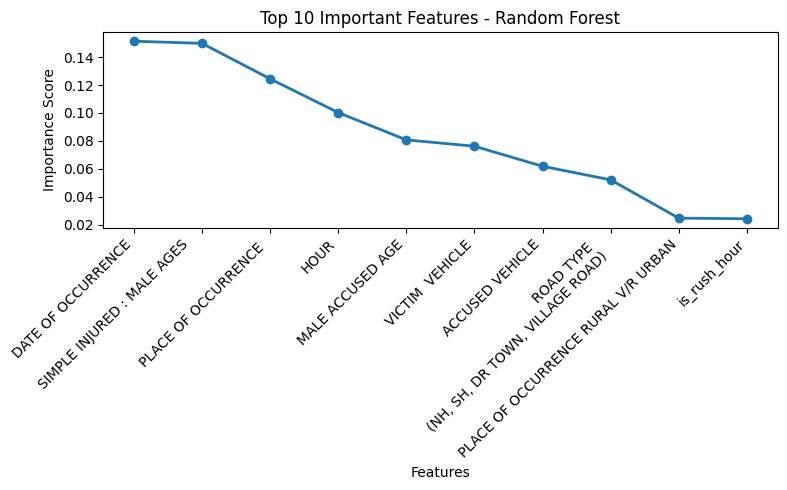

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

importances = model.feature_importances_
feature_names = np.array(X_train.columns)

# Top 10
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(8,5))
plt.plot(range(len(indices)), importances[indices], marker='o', linewidth=2)
plt.xticks(range(len(indices)), feature_names[indices], rotation=45, ha='right')
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()


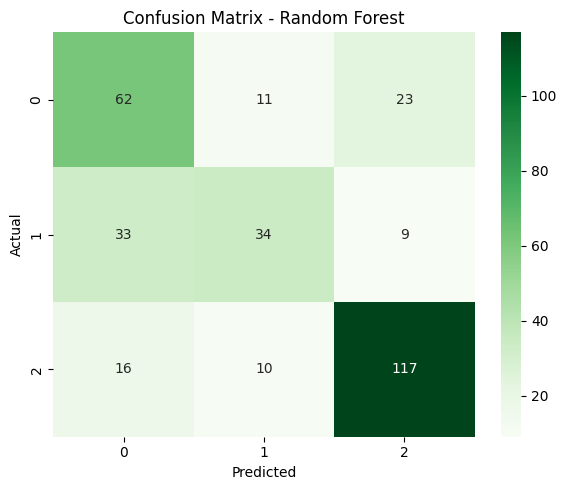

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# **XG BOOST**

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, pred_xgb))
print(classification_report(y_test, pred_xgb))


XGBoost Accuracy: 0.6571428571428571
              precision    recall  f1-score   support

           0       0.57      0.55      0.56        96
           1       0.57      0.47      0.52        76
           2       0.74      0.83      0.78       143

    accuracy                           0.66       315
   macro avg       0.63      0.62      0.62       315
weighted avg       0.65      0.66      0.65       315



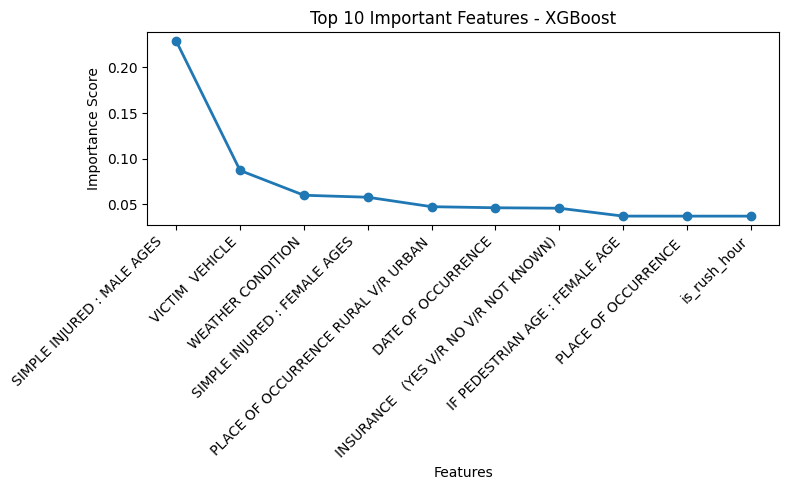

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

importances = xgb.feature_importances_
feature_names = np.array(X_train.columns)

# Top 10
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(8,5))
plt.plot(range(len(indices)), importances[indices], marker='o', linewidth=2)
plt.xticks(range(len(indices)), feature_names[indices], rotation=45, ha='right')
plt.title("Top 10 Important Features - XGBoost")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()


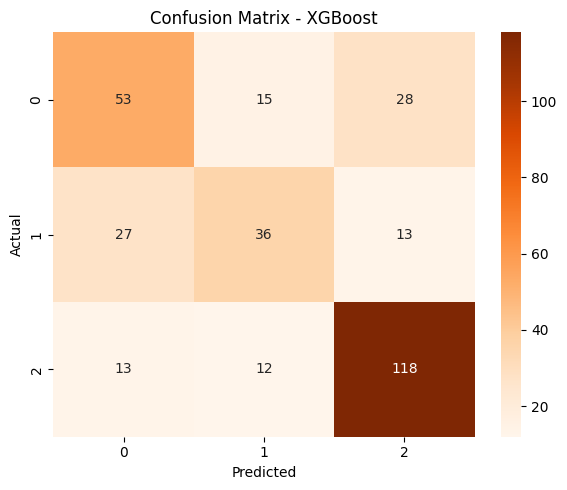

In [ ]:
cm_xgb = confusion_matrix(y_test, pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# **HistGradientBoosting**

In [ ]:
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

hgb = HistGradientBoostingClassifier()
hgb.fit(X_train, y_train)

pred_hgb = hgb.predict(X_test)
print("HGB Accuracy:", accuracy_score(y_test, pred_hgb))
print(classification_report(y_test, pred_hgb))


/usr/local/lib/python3.12/dist-packages/sklearn/experimental/enable_hist_gradient_boosting.py:19: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


HGB Accuracy: 0.638095238095238
              precision    recall  f1-score   support

           0       0.58      0.53      0.55        96
           1       0.51      0.49      0.50        76
           2       0.73      0.79      0.76       143

    accuracy                           0.64       315
   macro avg       0.61      0.60      0.60       315
weighted avg       0.63      0.64      0.63       315



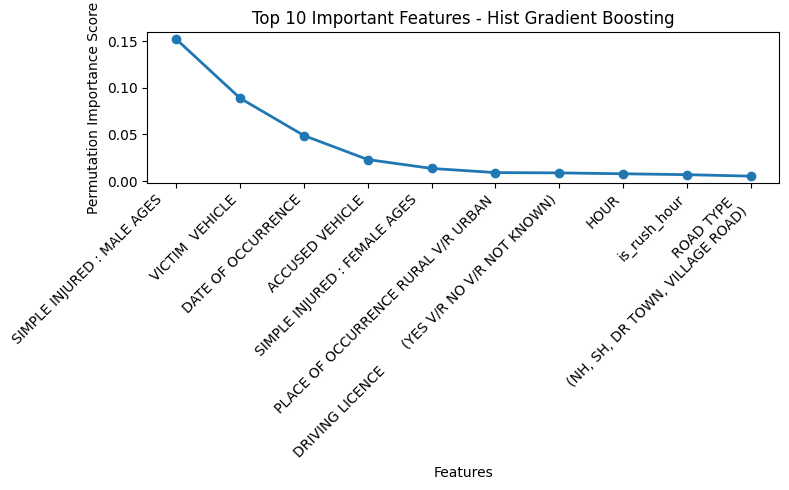

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

result = permutation_importance(hgb, X_test, y_test, n_repeats=10, random_state=42)

importances = result.importances_mean
feature_names = np.array(X_train.columns)
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(8,5))
plt.plot(range(len(indices)), importances[indices], marker='o', linewidth=2)
plt.xticks(range(len(indices)), feature_names[indices], rotation=45, ha='right')
plt.title("Top 10 Important Features - Hist Gradient Boosting")
plt.xlabel("Features")
plt.ylabel("Permutation Importance Score")
plt.tight_layout()
plt.show()


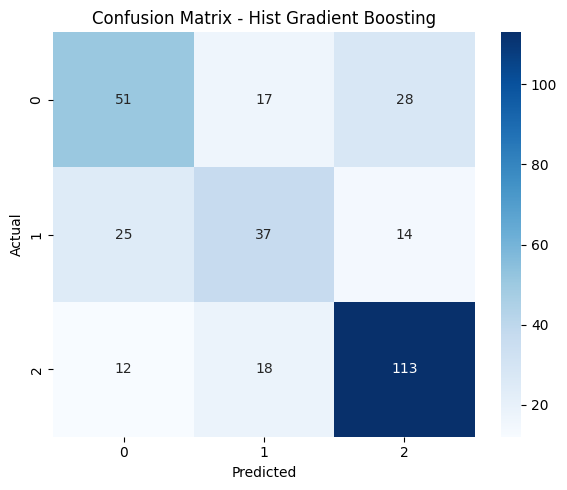

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred_hgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Hist Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
